In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv("../data/sudan.csv")
df['Country'] = 'Sudan'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Shape: (4108, 15)
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [3]:
df.replace(-999, np.nan, inplace=True)
print("Replaced all -999 with NaN")

Replaced all -999 with NaN


In [4]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows found: 0
Shape after dropping duplicates: (4108, 15)


In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


## Summary Statistics Interpretation
- Sudan being a Saharan/semi-arid country shows very high T2M values — some of the hottest in Africa
- PRECTOTCORR is very low with extreme variability — long dry seasons dominate
- T2M_RANGE is large reflecting typical desert climate with massive day/night swings
- RH2M is very low confirming arid desert conditions

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print("=== Missing Value Report ===")
print(missing_report[missing_report['Missing Count'] > 0])
print("\nColumns with >5% missing:")
print(missing_report[missing_report['Missing %'] > 5])

=== Missing Value Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Columns with >5% missing:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [7]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN',
                 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

print("=== Outlier Report (|Z| > 3) ===")
for col in cols_to_check:
    if col in df.columns:
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outliers = (z_scores > 3).sum()
        print(f"{col}: {outliers} outliers")

=== Outlier Report (|Z| > 3) ===
T2M: 3 outliers
T2M_MAX: 6 outliers
T2M_MIN: 1 outliers
PRECTOTCORR: 71 outliers
RH2M: 3 outliers
WS2M: 4 outliers
WS2M_MAX: 3 outliers


In [8]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
                'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX',
                'PS', 'QV2M']

df[weather_cols] = df[weather_cols].ffill()
print(f"Forward fill applied. Remaining missing: {df.isna().sum().sum()}")

df.to_csv("../data/sudan_clean.csv", index=False)
print("Exported to data/sudan_clean.csv")

Forward fill applied. Remaining missing: 0
Exported to data/sudan_clean.csv


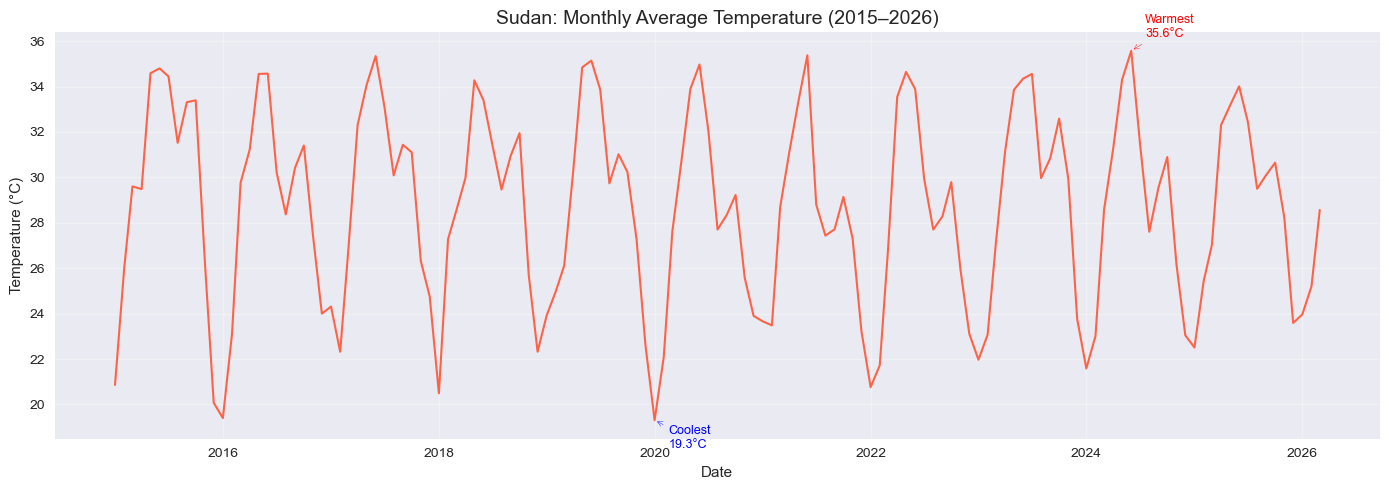

Saved!


In [9]:
monthly_temp = df.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['YEAR', 'Month']].assign(DAY=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_temp['Date'], monthly_temp['T2M'], color='tomato', linewidth=1.5)

warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

ax.annotate(f"Warmest\n{warmest['T2M']:.1f}°C",
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points',
            color='red', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'))

ax.annotate(f"Coolest\n{coolest['T2M']:.1f}°C",
            xy=(coolest['Date'], coolest['T2M']),
            xytext=(10, -20), textcoords='offset points',
            color='blue', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='blue'))

ax.set_title('Sudan: Monthly Average Temperature (2015–2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/sudan_temp_timeseries.png', dpi=150)
plt.show()
print("Saved!")

## Temperature Trend Interpretation
- Sudan records among the highest temperatures in the dataset — regularly exceeding 35°C
- Peak heat occurs April–June before the brief rainy season provides slight relief
- Coolest months are December–January but still warm by global standards
- A gradual warming trend is visible over the 2015–2026 period

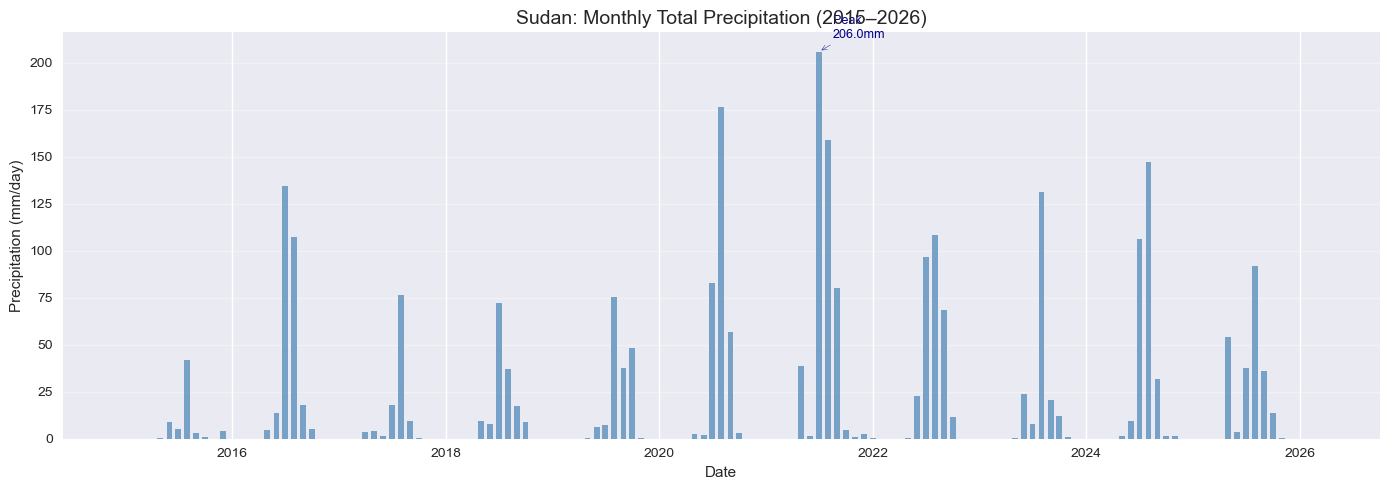

Saved!


In [10]:
monthly_precip = df.groupby(['YEAR', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(
    monthly_precip[['YEAR', 'Month']].assign(DAY=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_precip['Date'], monthly_precip['PRECTOTCORR'],
       color='steelblue', width=20, alpha=0.7)

peak = monthly_precip.loc[monthly_precip['PRECTOTCORR'].idxmax()]
ax.annotate(f"Peak\n{peak['PRECTOTCORR']:.1f}mm",
            xy=(peak['Date'], peak['PRECTOTCORR']),
            xytext=(10, 10), textcoords='offset points',
            color='darkblue', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='darkblue'))

ax.set_title('Sudan: Monthly Total Precipitation (2015–2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm/day)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../notebooks/sudan_precip_timeseries.png', dpi=150)
plt.show()
print("Saved!")

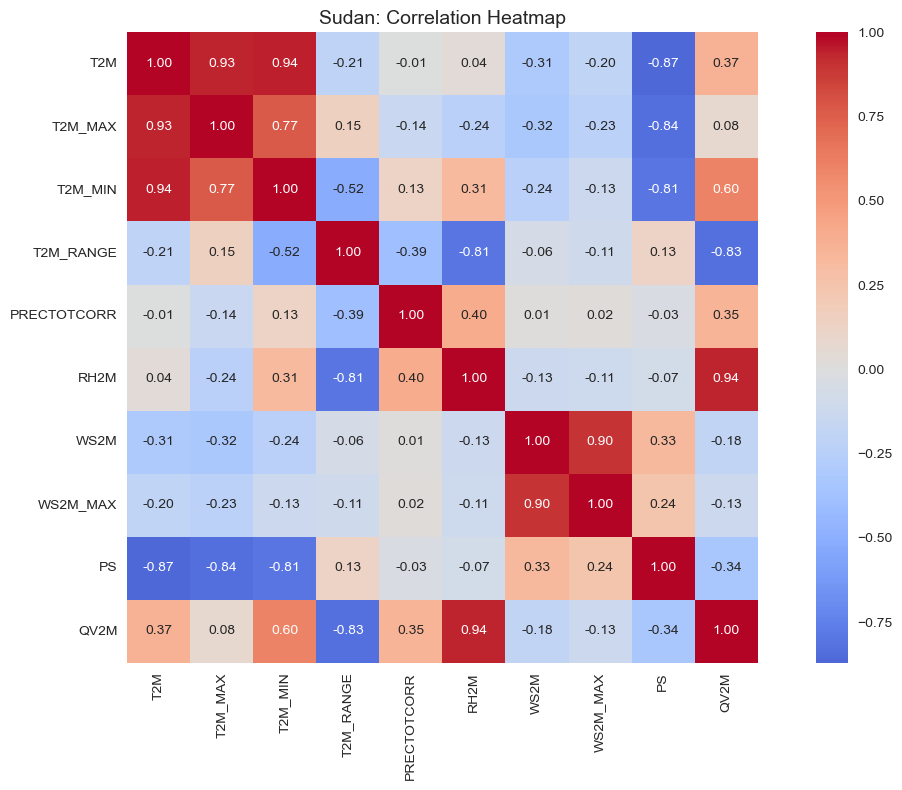

Saved!


In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
                'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX',
                'PS', 'QV2M']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Sudan: Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/sudan_correlation_heatmap.png', dpi=150)
plt.show()
print("Saved!")

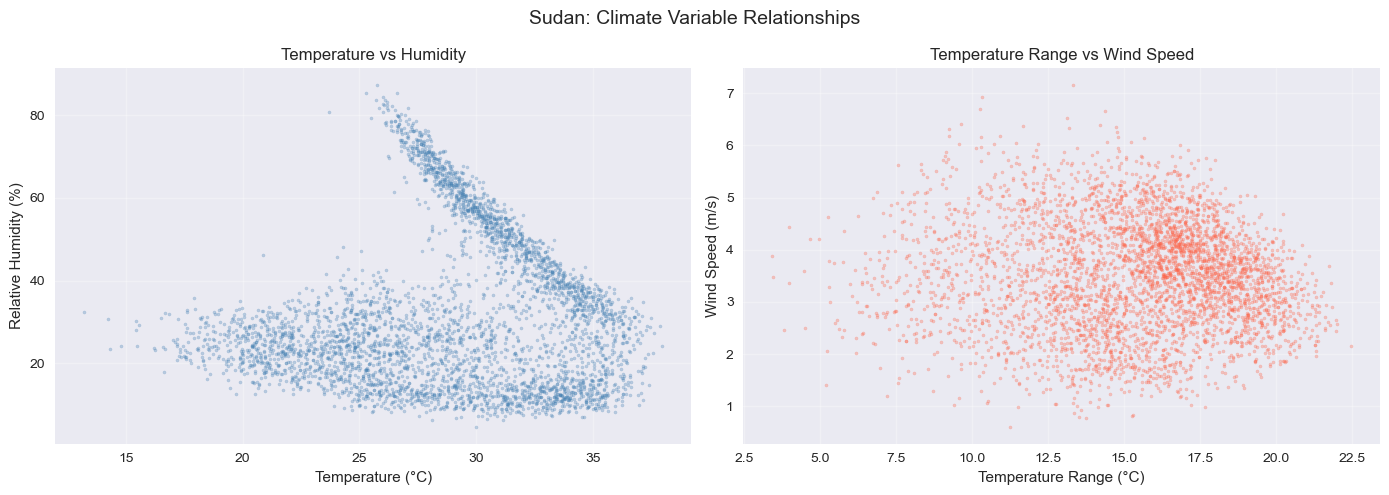

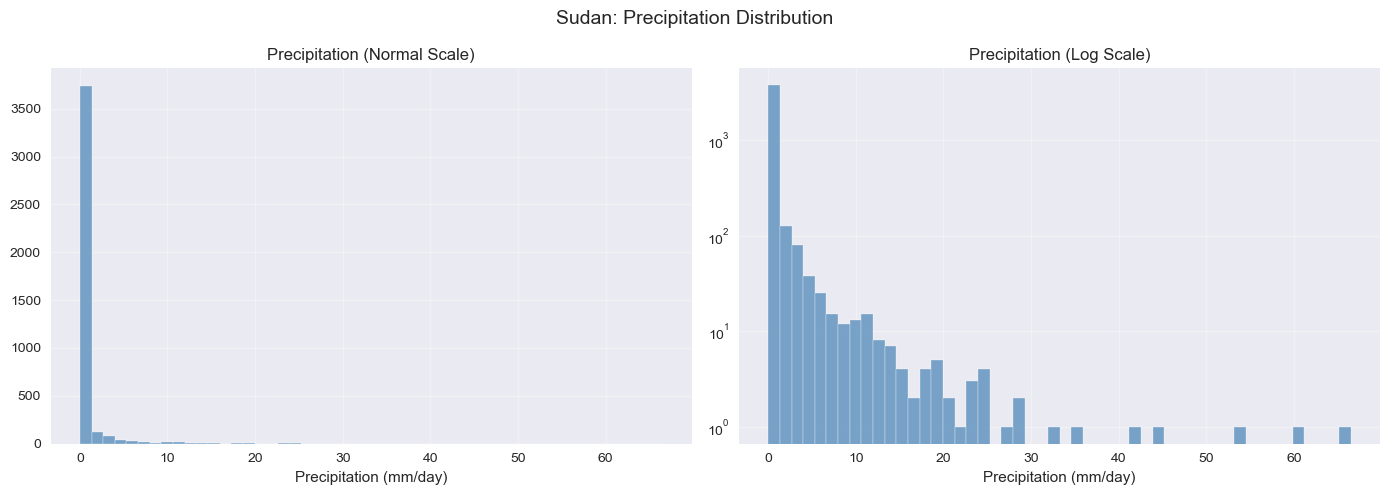

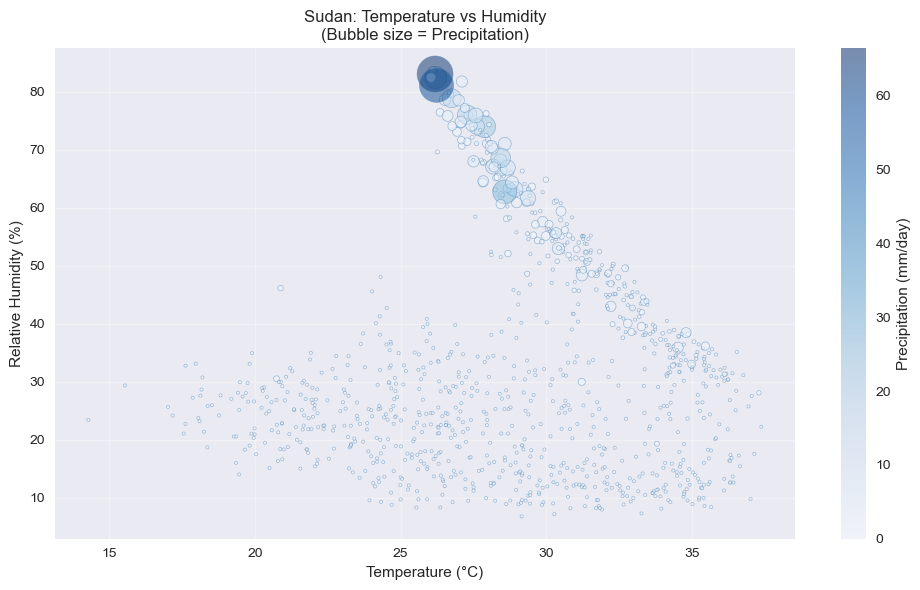

All plots saved!


In [12]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, color='steelblue', s=5)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Humidity')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='tomato', s=5)
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sudan: Climate Variable Relationships', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/sudan_scatter_plots.png', dpi=150)
plt.show()

# Precipitation histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50,
             color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_title('Precipitation (Normal Scale)')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['PRECTOTCORR'].dropna() + 0.01, bins=50,
             color='steelblue', edgecolor='white', alpha=0.7, log=True)
axes[1].set_title('Precipitation (Log Scale)')
axes[1].set_xlabel('Precipitation (mm/day)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sudan: Precipitation Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/sudan_precip_distribution.png', dpi=150)
plt.show()

# Bubble chart
sample = df.sample(n=1000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(sample['T2M'], sample['RH2M'],
                     s=sample['PRECTOTCORR'] * 10 + 5,
                     c=sample['PRECTOTCORR'],
                     cmap='Blues', alpha=0.5,
                     edgecolors='steelblue', linewidth=0.5)
plt.colorbar(scatter, label='Precipitation (mm/day)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')
ax.set_title('Sudan: Temperature vs Humidity\n(Bubble size = Precipitation)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/sudan_bubble_chart.png', dpi=150)
plt.show()
print("All plots saved!")